# Fuzzy C-Means Clustering with scikit-fuzzy

This notebook mirrors the workflow from `clustering_analysis.ipynb`, but swaps the clustering backend for **scikit-fuzzy** so we can experiment with soft assignments. We will:

- Load the preprocessed geometric features via `load_and_prepare_data()`
- Reshape the feature matrix into the `(features, samples)` layout expected by scikit-fuzzy
- Sweep over several fuzzifier values `m` and compare their Fuzzy Partition Coefficient (FPC)
- Lock in the best `m`, run the final model, convert memberships to hard labels, and compute Adjusted Rand Index (ARI)
- Visualize true vs. predicted clusters using PCA projections and membership plots



In [2]:
%pip install scikit-fuzzy --quiet


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import skfuzzy as fuzz

from preprocess4 import load_and_prepare_data, DEFAULT_OUTPUT_FILE
from visualize_clusters import visualize_clusters_with_images, compare_clusters_vs_true_labels

# ---------------------------------------------------------------------------
# Configuration - mirror the knobs from clustering_analysis.ipynb when useful
# ---------------------------------------------------------------------------
SELECTED_EMOTIONS = ['Happy', 'Sad', 'Surprised', 'Anger', 'Contempt', 'Disgust', 'Fear', 'Neutral']
NUM_RANDOM_SAMPLES = 0  # draw additional samples from other emotions

# Number of clusters (fixed per user request)
FORCED_C = 7
M_FOR_C_SEARCH = 1.4   # industry-standard default for diagnostics

# Step 2 (tune m): range of fuzzifier values for the chosen c
M_RANGE = np.round(np.linspace(1.1, 2.0, 20), 2)  # dense grid from 1.1 to 3.0

FMC_ERROR = 1e-5
FMC_MAXITER = 1000
RANDOM_STATE = 42

_BASE_DIR = Path.cwd() if Path.cwd().name == 'four' else Path.cwd() / 'four'
print(f"Notebook base directory: {_BASE_DIR}")
print(f"Selected emotions: {SELECTED_EMOTIONS if SELECTED_EMOTIONS else 'ALL'}")


MediaPipe is required for Phase A (preprocessing).
You may need to resolve protobuf version conflicts between MediaPipe and TensorFlow.
Try: pip install 'protobuf>=4.25.3,<5.0.0'
Notebook base directory: c:\Users\nicos\lokaleprosjekter\GitHub\IT3212\four
Selected emotions: ['Happy', 'Sad', 'Surprised', 'Anger', 'Contempt', 'Disgust', 'Fear', 'Neutral']


In [4]:
# ---------------------------------------------------------------------------
# Load and prepare data (Phase B)
# ---------------------------------------------------------------------------
X_scaled, y_labels, scaler, selected_idx = load_and_prepare_data(
    csv_path=DEFAULT_OUTPUT_FILE,
    emotions=SELECTED_EMOTIONS,
    num_randoms=NUM_RANDOM_SAMPLES,
)

n_samples, n_features = X_scaled.shape
unique_labels = np.unique(y_labels)
n_clusters = len(unique_labels)

print(f"Feature matrix shape (samples, features): {X_scaled.shape}")
print(f"scikit-fuzzy expected shape (features, samples): {(n_features, n_samples)}")

# Convert labels to numeric ids for metrics
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)

# scikit-fuzzy wants (features, samples)
fcm_data = X_scaled.T
assert fcm_data.shape == (n_features, n_samples)
print("Data transposed successfully for scikit-fuzzy.")
print(f"Number of clusters inferred from labels: {n_clusters}")


Selected 152 samples:
  From specified emotions ['Happy', 'Sad', 'Surprised', 'Anger', 'Contempt', 'Disgust', 'Fear', 'Neutral']: 152 samples
  Emotion distribution:
    Anger: 19
    Contempt: 19
    Disgust: 19
    Fear: 19
    Happy: 19
    Neutral: 19
    Sad: 19
    Surprised: 19
Feature matrix shape (samples, features): (152, 10)
scikit-fuzzy expected shape (features, samples): (10, 152)
Data transposed successfully for scikit-fuzzy.
Number of clusters inferred from labels: 8


In [5]:
def run_fcm(data: np.ndarray, c: int, m: float, *, error: float = FMC_ERROR,
            maxiter: int = FMC_MAXITER, seed: int = RANDOM_STATE):
    """Wrapper around skfuzzy.cmeans with consistent kwargs."""
    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        data=data,
        c=c,
        m=m,
        error=error,
        maxiter=maxiter,
        init=None,
        seed=seed,
    )
    return {
        "centers": cntr,
        "memberships": u,
        "initial_memberships": u0,
        "distances": d,
        "objective_history": jm,
        "n_iterations": p,
        "fpc": fpc,
    }


def evaluate_c_values(data: np.ndarray, m_fixed: float, c_values: range) -> pd.DataFrame:
    """Step 1: sweep over number of clusters c using the fuzzy objective function Jm.

    Returns a DataFrame with columns: c, Objective, Iterations.
    """
    rows = []
    for c in c_values:
        result = run_fcm(data, c=c, m=m_fixed)
        jm_final = result["objective_history"][-1]
        rows.append({
            "c": c,
            "Objective": jm_final,
            "Iterations": result["n_iterations"],
        })
        print(f"c={c} (m={m_fixed:.2f}) -> Jm={jm_final:.4f} in {result['n_iterations']} iters")
    return pd.DataFrame(rows)


def evaluate_fuzzifier_values(data: np.ndarray, c: int, m_values: List[float]) -> pd.DataFrame:
    """Step 2: sweep over fuzzifier m for a fixed c, collect FPC."""
    rows = []
    for m in m_values:
        result = run_fcm(data, c=c, m=m)
        rows.append({
            "m": m,
            "FPC": result["fpc"],
            "Iterations": result["n_iterations"],
        })
        print(f"m={m:.2f} (c={c}) -> FPC={result['fpc']:.4f} in {result['n_iterations']} iters")
    return pd.DataFrame(rows)


def calculate_mpc(fpc: float, c: int) -> float:
    """Calculate Modified Partition Coefficient (MPC) from FPC and number of clusters.
    
    MPC = 1 - (c/(c-1)) * (1 - FPC)
    
    This normalizes FPC to account for the number of clusters, making it more
    comparable across different values of c. Higher MPC is better.
    """
    if c <= 1:
        return np.nan
    return 1 - (c / (c - 1)) * (1 - fpc)


def calculate_xie_beni(data: np.ndarray, centers: np.ndarray, membership: np.ndarray, m: float = 2.0) -> float:
    """Compute Xie-Beni (XB) index for fuzzy c-means results.

    data: (n_features, n_samples)
    centers: (n_clusters, n_features)
    membership: (n_clusters, n_samples)
    """
    n_clusters = centers.shape[0]
    n_samples = data.shape[1]

    # 1. Compactness (numerator)
    compactness = 0.0
    for i in range(n_clusters):
        diff = data.T - centers[i]  # (samples, features)
        sq_dist = np.sum(diff ** 2, axis=1)
        compactness += np.sum((membership[i] ** m) * sq_dist)

    # 2. Separation (denominator)
    min_sep = np.inf
    for i in range(n_clusters):
        for j in range(i + 1, n_clusters):
            dist = np.sum((centers[i] - centers[j]) ** 2)
            if dist < min_sep:
                min_sep = dist

    separation = n_samples * min_sep
    return compactness / (separation + 1e-10)



In [6]:
# ---------------------------------------------------------------------------
# Step 1: Force the number of clusters (user request)
# ---------------------------------------------------------------------------
best_c = FORCED_C
print(f"Step 1 skipped: using forced c = {best_c}")
print("You can adjust FORCED_C in the configuration cell if needed.")


Step 1 skipped: using forced c = 7
You can adjust FORCED_C in the configuration cell if needed.


Computing MPC and Xie-Beni (XB) curves across cluster counts for diagnostics...
c=2: MPC=0.6596, XB=0.6057
c=3: MPC=0.6031, XB=1.0180
c=4: MPC=0.6347, XB=0.5955
c=5: MPC=0.5828, XB=1.0547
c=6: MPC=0.6242, XB=0.9132
c=7: MPC=0.5986, XB=0.7952
c=8: MPC=0.5976, XB=0.8491
c=9: MPC=0.5853, XB=1.2137
c=10: MPC=0.5999, XB=1.0839


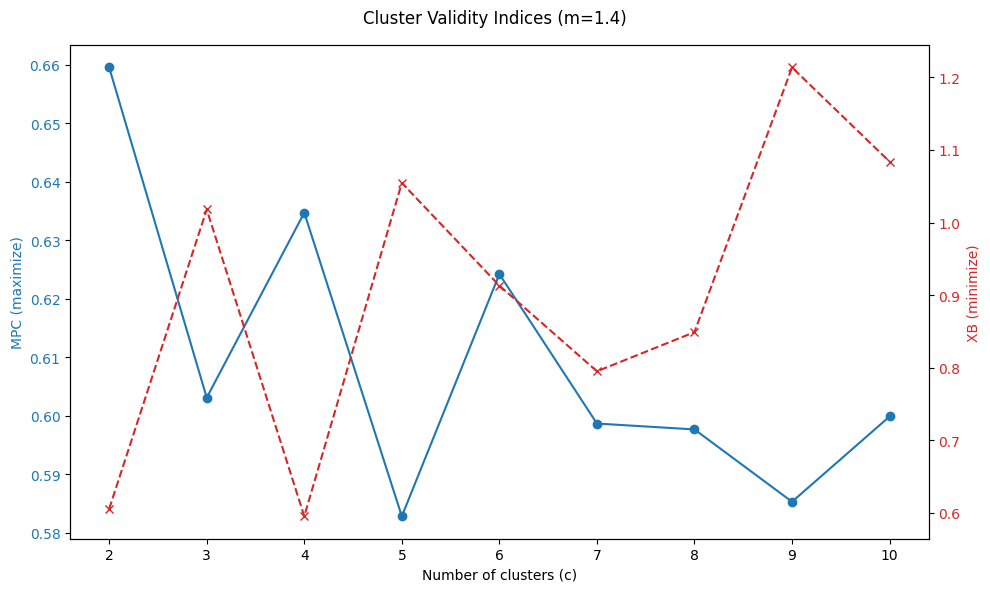

In [7]:
# ---------------------------------------------------------------------------
# Diagnostic: Plot MPC (Modified Partition Coefficient) and XB index vs c
# ---------------------------------------------------------------------------
print("Computing MPC and Xie-Beni (XB) curves across cluster counts for diagnostics...")
validity_c_range = range(2, 11)  # visualize 2..10 clusters
mpc_curve, xb_curve = [], []

for c in validity_c_range:
    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        fcm_data, c=c, m=M_FOR_C_SEARCH, error=FMC_ERROR, maxiter=FMC_MAXITER, seed=RANDOM_STATE
    )
    mpc = calculate_mpc(fpc, c)
    mpc_curve.append(mpc)
    xb = calculate_xie_beni(fcm_data, cntr, u, m=M_FOR_C_SEARCH)
    xb_curve.append(xb)
    print(f"c={c}: MPC={mpc:.4f}, XB={xb:.4f}")

fig, ax1 = plt.subplots(figsize=(10, 6))
color = 'tab:blue'
ax1.set_xlabel('Number of clusters (c)')
ax1.set_ylabel('MPC (maximize)', color=color)
ax1.plot(list(validity_c_range), mpc_curve, marker='o', color=color, label='MPC')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('XB (minimize)', color=color)
ax2.plot(list(validity_c_range), xb_curve, marker='x', linestyle='--', color=color, label='XB')
ax2.tick_params(axis='y', labelcolor=color)

fig.suptitle(f'Cluster Validity Indices (m={M_FOR_C_SEARCH})')
fig.tight_layout()
plt.grid(True, axis='x')
plt.show()



Step 2: Searching for best m for c = 7 using Xie-Beni (XB) index...
m=1.10: XB=1.1683, FPC=0.9555
m=1.15: XB=0.8190, FPC=0.9107
m=1.19: XB=0.8240, FPC=0.8698
m=1.24: XB=0.8130, FPC=0.8131
m=1.29: XB=0.8091, FPC=0.7629
m=1.34: XB=0.8017, FPC=0.7146
m=1.38: XB=0.7971, FPC=0.6755
m=1.43: XB=0.7929, FPC=0.6269
m=1.48: XB=0.8587, FPC=0.5795
m=1.53: XB=0.8513, FPC=0.5324
m=1.57: XB=0.8451, FPC=0.4967
m=1.62: XB=1.0343, FPC=0.4213
m=1.67: XB=1.1207, FPC=0.3815
m=1.72: XB=2.5629, FPC=0.3306
m=1.76: XB=2.6966, FPC=0.3083
m=1.81: XB=2.9143, FPC=0.2836
m=1.86: XB=3.2900, FPC=0.2622
m=1.91: XB=4.0848, FPC=0.2436
m=1.95: XB=5.9255, FPC=0.2306
m=2.00: XB=2329171.1439, FPC=0.2137
--------------------------------------------------------------------------------
XB vs m:
1.10    1.168347e+00
1.15    8.190300e-01
1.19    8.239909e-01
1.24    8.129808e-01
1.29    8.090581e-01
1.34    8.017050e-01
1.38    7.970560e-01
1.43    7.929444e-01
1.48    8.586699e-01
1.53    8.513050e-01
1.57    8.451307e-01
1.62 

C:\Users\nicos\AppData\Local\Temp\ipykernel_25112\1504602134.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


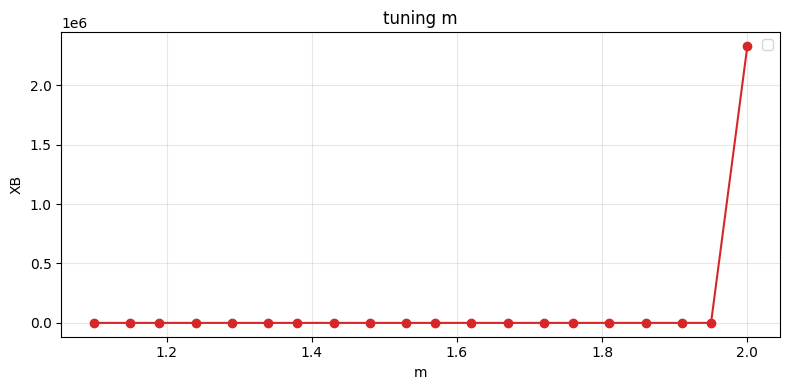

1.10    1.168347e+00
1.15    8.190300e-01
1.19    8.239909e-01
1.24    8.129808e-01
1.29    8.090581e-01
1.34    8.017050e-01
1.38    7.970560e-01
1.43    7.929444e-01
1.48    8.586699e-01
1.53    8.513050e-01
1.57    8.451307e-01
1.62    1.034266e+00
1.67    1.120685e+00
1.72    2.562884e+00
1.76    2.696628e+00
1.81    2.914318e+00
1.86    3.289956e+00
1.91    4.084784e+00
1.95    5.925464e+00
2.00    2.329171e+06
Name: XB, dtype: float64

In [8]:
# ---------------------------------------------------------------------------
# Step 2: Tune fuzzifier m for the chosen c using XB index
# ---------------------------------------------------------------------------
print("Step 2: Searching for best m for c =", best_c, "using Xie-Beni (XB) index...")

m_values = list(M_RANGE)
xb_values = []
fpc_values = []  # optional: keep for inspection

for m in m_values:
    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        fcm_data, c=best_c, m=m, error=FMC_ERROR, maxiter=FMC_MAXITER, seed=RANDOM_STATE
    )
    xb = calculate_xie_beni(fcm_data, cntr, u, m=m)
    xb_values.append(xb)
    fpc_values.append(fpc)
    print(f"m={m:.2f}: XB={xb:.4f}, FPC={fpc:.4f}")

xb_series = pd.Series(xb_values, index=m_values, name="XB")
# Choose m that minimizes XB
best_m = float(xb_series.idxmin())
print("-" * 80)
print("XB vs m:")
print(xb_series)
print("-" * 80)
print(f"Chosen m = {best_m:.2f} (minimum XB for c={best_c})")

plt.figure(figsize=(8, 4))
plt.plot(m_values, xb_values, marker='o', color='tab:red')
plt.title(f'tuning m')
plt.xlabel('m')
plt.ylabel('XB')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

xb_series


In [9]:
final_result = run_fcm(fcm_data, c=best_c, m=best_m)
memberships = final_result['memberships']  # shape (clusters, samples)
hard_labels = np.argmax(memberships, axis=0)

ari_score = adjusted_rand_score(y_encoded, hard_labels)
print(f"Final model -> c={best_c}, m={best_m:.2f}, FPC={final_result['fpc']:.4f}, ARI={ari_score:.4f}")

membership_df = pd.DataFrame(
    memberships.T,
    columns=[f"Cluster_{i}" for i in range(best_c)]
)
membership_df['Hard_Label'] = hard_labels
membership_df['True_Label'] = y_labels
membership_df['Converted_Label'] = label_encoder.inverse_transform(hard_labels.clip(max=len(label_encoder.classes_)-1))

membership_df.head()


Final model -> c=7, m=1.43, FPC=0.6269, ARI=0.1157


,Cluster_0,Cluster_1,Cluster_2,Cluster_3,Cluster_4,Cluster_5,Cluster_6,Hard_Label,True_Label,Converted_Label
0,0.012772,0.973219,0.000042,0.001163,0.000205,0.000943,0.011656,1,Anger,Contempt
1,0.084410,0.806503,0.000210,0.007752,0.001006,0.005861,0.094259,1,Contempt,Contempt
2,0.250969,0.351196,0.000876,0.020846,0.005468,0.016921,0.353725,6,Disgust,Sad
3,0.008752,0.003195,0.001471,0.001847,0.968309,0.013548,0.002878,4,Fear,Happy
4,0.045930,0.026113,0.001658,0.601346,0.003443,0.009639,0.311872,3,Happy,Fear


In [10]:
# Convert soft memberships (probabilities) into binary hard assignments per sample
hard_indicator = np.zeros_like(memberships)
hard_indicator[hard_labels, np.arange(n_samples)] = 1

conversion_example = pd.DataFrame({
    "True_Label": y_labels[:5],
    "Hard_Label": hard_labels[:5],
    "Membership_Vector": list(memberships.T[:5]),
    "Binary_Vector": list(hard_indicator.T[:5])
})
conversion_example


,True_Label,Hard_Label,Membership_Vector,Binary_Vector
0,Anger,1,"[0.012771870515886284, 0.9732194008677401, 4.1...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
1,Contempt,1,"[0.08440962088465036, 0.8065030599546793, 0.00...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
2,Disgust,6,"[0.250968572768726, 0.3511959793202614, 0.0008...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0]"
3,Fear,4,"[0.008752063832937284, 0.0031945508967768095, ...","[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0]"
4,Happy,3,"[0.04593023934081511, 0.026112628553894155, 0....","[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0]"


Computing t-SNE embedding (this may take a moment)...


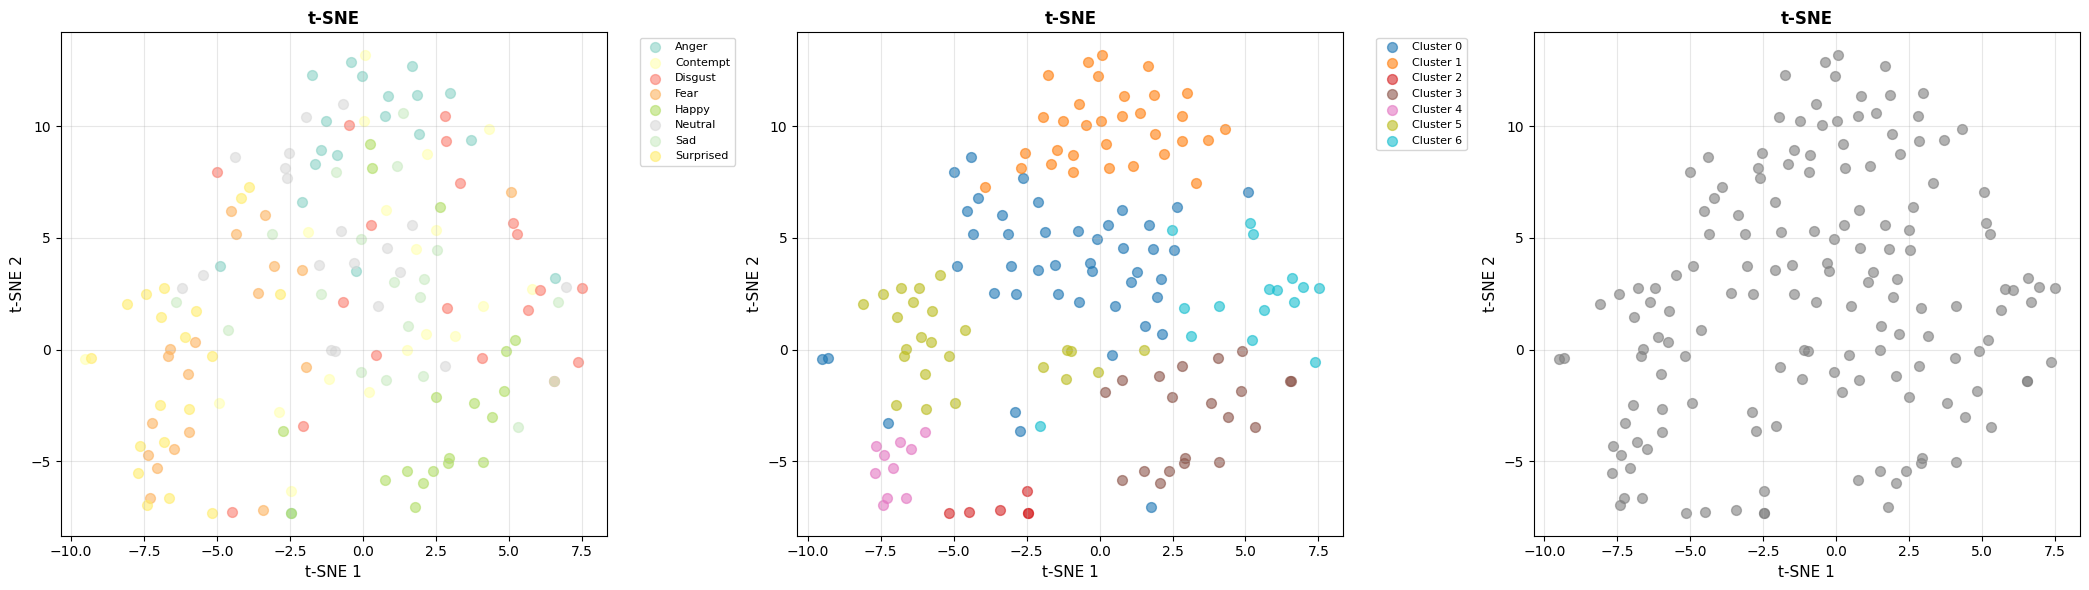

In [11]:
# ---------------------------------------------------------------------------
# Visual comparison: true vs. predicted clusters using t-SNE
# ---------------------------------------------------------------------------
print("Computing t-SNE embedding (this may take a moment)...")
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Plot 1: True labels
unique_true = sorted(set(y_labels))
colors_true = plt.cm.Set3(np.linspace(0, 1, len(unique_true)))
for i, label in enumerate(unique_true):
    mask = y_labels == label
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
                   c=[colors_true[i]], label=label, alpha=0.6, s=50)
axes[0].set_xlabel('t-SNE 1', fontsize=11)
axes[0].set_ylabel('t-SNE 2', fontsize=11)
axes[0].set_title('t-SNE', fontsize=12, fontweight='bold')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[0].grid(True, alpha=0.3)

# Plot 2: Predicted clusters
unique_clusters = sorted(set(hard_labels))
colors_clusters = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))
for i, cluster_id in enumerate(unique_clusters):
    mask = hard_labels == cluster_id
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
                   c=[colors_clusters[i]], label=f'Cluster {cluster_id}', alpha=0.6, s=50)
axes[1].set_xlabel('t-SNE 1', fontsize=11)
axes[1].set_ylabel('t-SNE 2', fontsize=11)
axes[1].set_title('t-SNE', fontsize=12, fontweight='bold')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[1].grid(True, alpha=0.3)

# Plot 3: All points same color (no clustering)
axes[2].scatter(X_tsne[:, 0], X_tsne[:, 1], c='gray', alpha=0.6, s=50)
axes[2].set_xlabel('t-SNE 1', fontsize=11)
axes[2].set_ylabel('t-SNE 2', fontsize=11)
axes[2].set_title('t-SNE', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



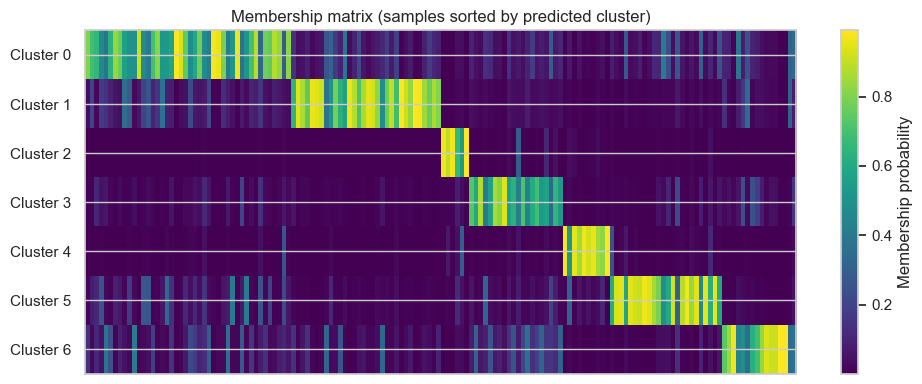

In [12]:
# Membership strength overview
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 4))
ordered_idx = np.argsort(hard_labels)
plt.imshow(memberships[:, ordered_idx], aspect='auto', cmap='viridis')
plt.colorbar(label='Membership probability')
plt.yticks(range(best_c), [f'Cluster {i}' for i in range(best_c)])
plt.xticks([])
plt.title('Membership matrix (samples sorted by predicted cluster)')
plt.tight_layout()
plt.show()



VISUALIZING IMAGES BY CLUSTER
Using provided selected_indices: 152 samples


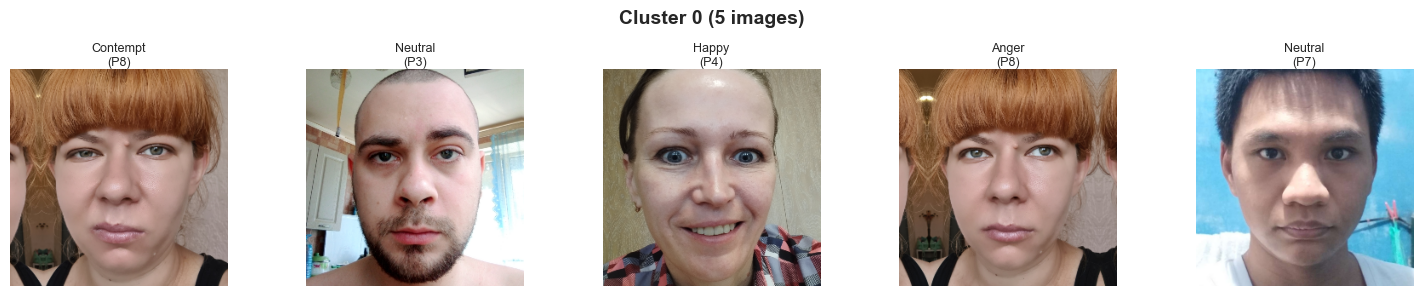

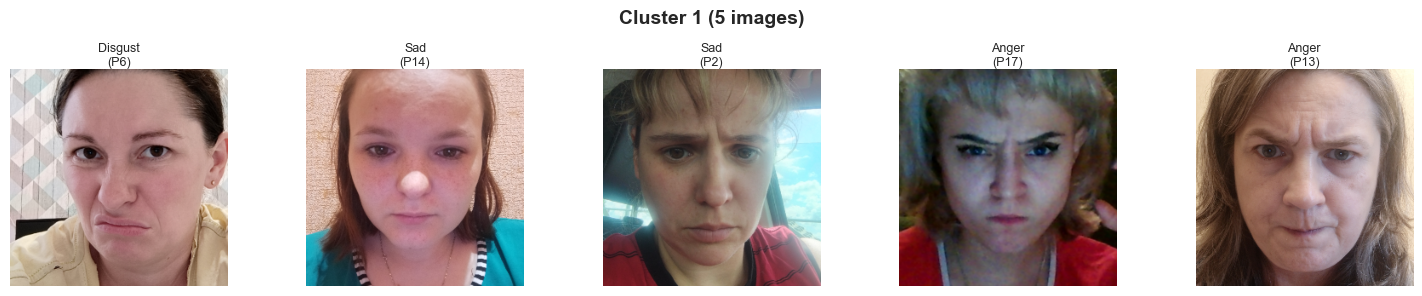

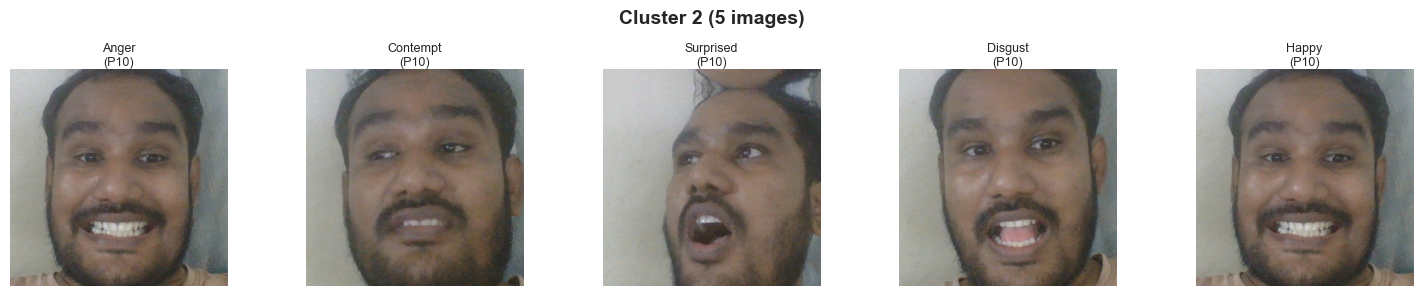

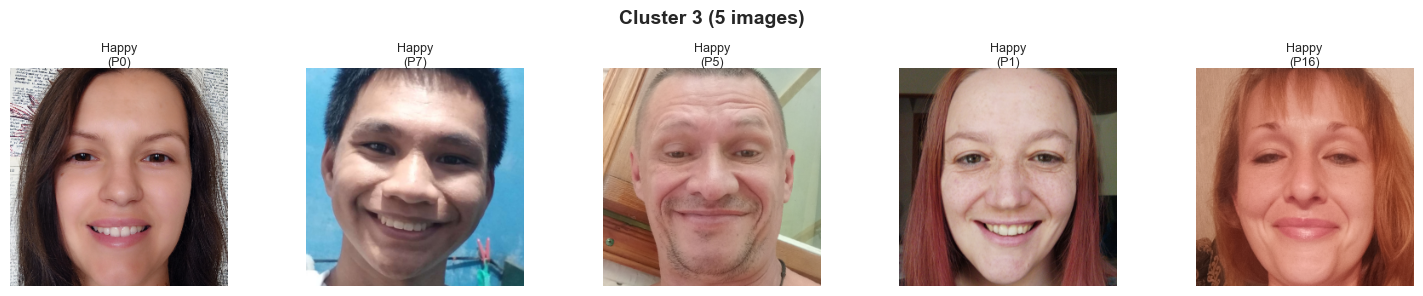

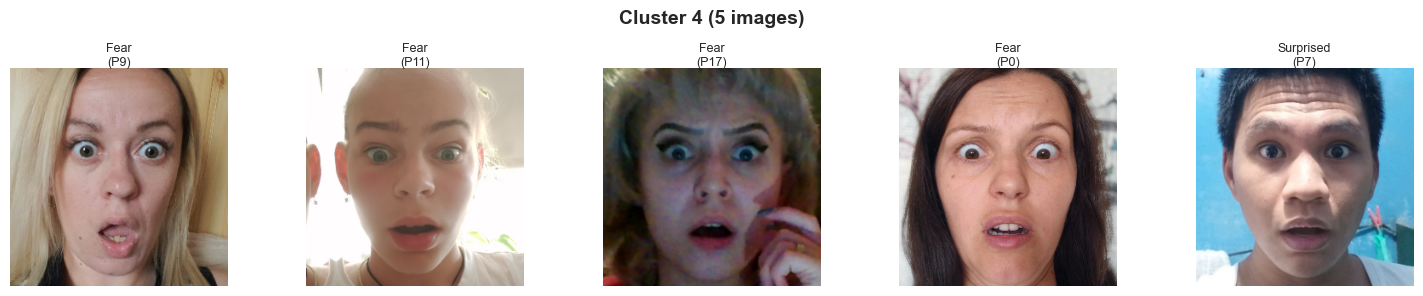

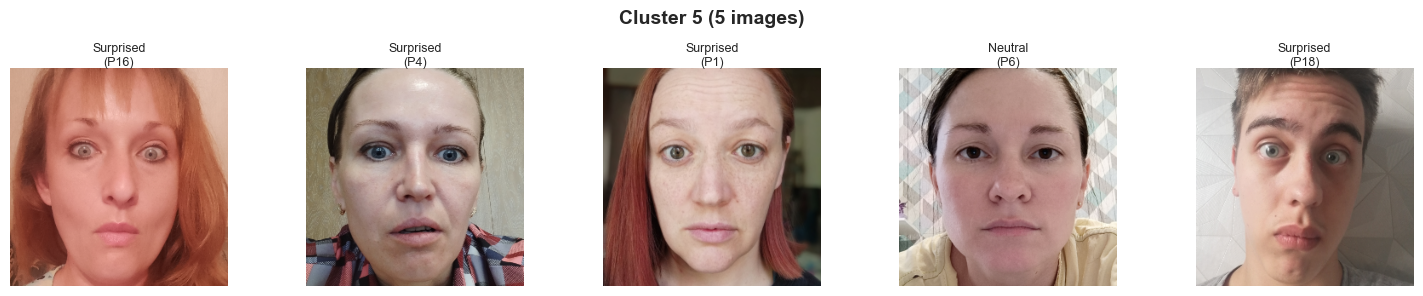

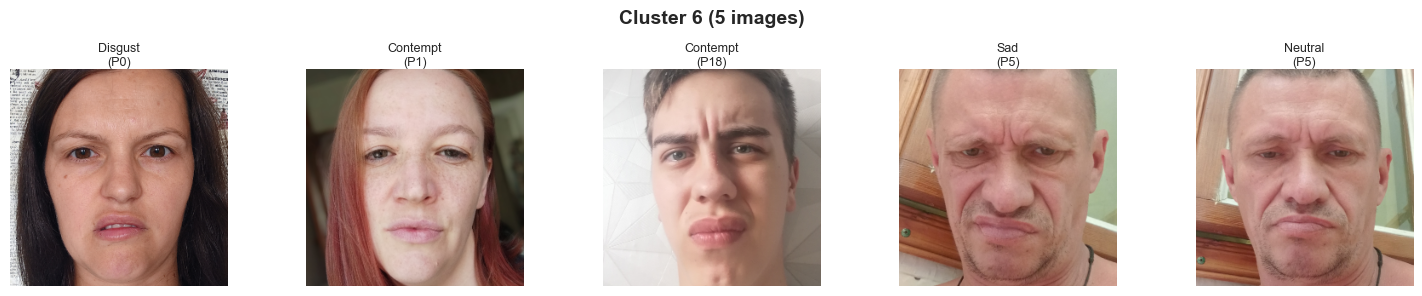


Fuzzy C-Means (c=7, m=1.43) - Cluster Summary:

Cluster 0: 44 samples
  True label distribution:
    Neutral: 9 (20.5%)
    Sad: 8 (18.2%)
    Fear: 8 (18.2%)
    Contempt: 6 (13.6%)
    Disgust: 4 (9.1%)
    Anger: 3 (6.8%)
    Surprised: 3 (6.8%)
    Happy: 3 (6.8%)

Cluster 1: 32 samples
  True label distribution:
    Anger: 14 (43.8%)
    Contempt: 4 (12.5%)
    Neutral: 4 (12.5%)
    Disgust: 4 (12.5%)
    Sad: 3 (9.4%)
    Happy: 2 (6.2%)
    Surprised: 1 (3.1%)

Cluster 2: 6 samples
  True label distribution:
    Anger: 1 (16.7%)
    Contempt: 1 (16.7%)
    Disgust: 1 (16.7%)
    Fear: 1 (16.7%)
    Happy: 1 (16.7%)
    Surprised: 1 (16.7%)

Cluster 3: 20 samples
  True label distribution:
    Happy: 12 (60.0%)
    Sad: 4 (20.0%)
    Disgust: 2 (10.0%)
    Neutral: 1 (5.0%)
    Contempt: 1 (5.0%)

Cluster 4: 10 samples
  True label distribution:
    Fear: 5 (50.0%)
    Surprised: 5 (50.0%)

Cluster 5: 24 samples
  True label distribution:
    Surprised: 9 (37.5%)
    Fear: 5 (2

In [13]:
# ---------------------------------------------------------------------------
# Visualize images by cluster (same method as clustering_analysis.ipynb)
# ---------------------------------------------------------------------------
print("=" * 80)
print("VISUALIZING IMAGES BY CLUSTER")
print("=" * 80)

# Determine the dataset folder path
DATASET_FOLDER = _BASE_DIR / 'facial_emotion_recognition_aligned'
if not DATASET_FOLDER.exists():
    # Fallback to the preprocessed folder
    DATASET_FOLDER = _BASE_DIR / 'facial_emotion_recognition_preprocessed2'

visualize_clusters_with_images(
    cluster_labels=hard_labels,
    true_labels=y_labels,
    csv_path=DEFAULT_OUTPUT_FILE,
    dataset_folder=DATASET_FOLDER,
    method_name=f'Fuzzy C-Means (c={best_c}, m={best_m:.2f})',
    max_images_per_cluster=5,  # Show only 5 images per cluster
    selected_indices=selected_idx  # Pass the exact indices used
)


In [14]:
# ---------------------------------------------------------------------------
# Edge Case Analysis: Split Memberships and Low-Confidence Outliers
# ---------------------------------------------------------------------------
def analyze_edge_cases(memberships: np.ndarray, hard_labels: np.ndarray, 
                       true_labels: np.ndarray, cluster_id: int = 0,
                       threshold: float = 0.3):
    """
    Analyze edge cases in fuzzy clustering:
    1. Samples in specified cluster with split memberships (high membership in multiple clusters)
    2. Top 5 samples with lowest overall certainty (lowest max membership across all clusters)
    
    Args:
        memberships: Membership matrix (n_clusters, n_samples)
        hard_labels: Hard cluster assignments (n_samples,)
        true_labels: True emotion labels (n_samples,)
        cluster_id: Cluster to analyze for split memberships (default: 0)
        threshold: Minimum membership in secondary cluster to consider "split" (default: 0.3)
    """
    n_samples = memberships.shape[1]
    
    # 1. Find samples in cluster_id with split memberships
    cluster_mask = hard_labels == cluster_id
    cluster_indices = np.where(cluster_mask)[0]
    
    split_cases = []
    for idx in cluster_indices:
        membership_vec = memberships[:, idx]  # (n_clusters,)
        primary_membership = membership_vec[cluster_id]
        
        # Find secondary cluster with highest membership (excluding primary)
        membership_vec_no_primary = membership_vec.copy()
        membership_vec_no_primary[cluster_id] = 0
        secondary_cluster = np.argmax(membership_vec_no_primary)
        secondary_membership = membership_vec[secondary_cluster]
        
        # Check if membership is split (secondary > threshold)
        if secondary_membership >= threshold:
            split_cases.append({
                'index': idx,
                'true_label': true_labels[idx],
                'primary_cluster': cluster_id,
                'primary_membership': primary_membership,
                'secondary_cluster': secondary_cluster,
                'secondary_membership': secondary_membership,
                'membership_vector': membership_vec
            })
    
    # 2. Find samples with lowest overall certainty (across ALL clusters)
    # Get max membership for each sample
    all_low_confidence = []
    for idx in range(n_samples):
        membership_vec = memberships[:, idx]
        max_membership = np.max(membership_vec)
        assigned_cluster = hard_labels[idx]
        assigned_membership = membership_vec[assigned_cluster]
        
        all_low_confidence.append({
            'index': idx,
            'true_label': true_labels[idx],
            'assigned_cluster': assigned_cluster,
            'assigned_membership': assigned_membership,
            'max_membership': max_membership,
            'membership_vector': membership_vec
        })
    
    # Sort by max_membership (lowest first) and take top 5
    all_low_confidence_sorted = sorted(all_low_confidence, key=lambda x: x['max_membership'])[:5]
    
    return split_cases, all_low_confidence_sorted


# Run analysis
print("=" * 80)
print("EDGE CASE ANALYSIS")
print("=" * 80)

split_cases, low_conf_outliers = analyze_edge_cases(
    memberships, hard_labels, y_labels, cluster_id=0, threshold=0.3
)

print(f"\n1. Split Membership Cases in Cluster 0:")
print(f"   Found {len(split_cases)} samples with split memberships (secondary >= 0.3)")
if len(split_cases) > 0:
    print(f"   Showing top 10 cases:")
    split_cases_sorted = sorted(split_cases, key=lambda x: x['secondary_membership'], reverse=True)[:10]
    for i, case in enumerate(split_cases_sorted, 1):
        print(f"   {i}. Sample {case['index']}: True={case['true_label']}, "
              f"Primary=Cluster {case['primary_cluster']} ({case['primary_membership']:.2%}), "
              f"Secondary=Cluster {case['secondary_cluster']} ({case['secondary_membership']:.2%})")

print(f"\n2. Lowest Overall Certainty Samples (Top 5):")
print(f"   Found {len(low_conf_outliers)} samples with lowest max membership")
if len(low_conf_outliers) > 0:
    for i, case in enumerate(low_conf_outliers, 1):
        print(f"   {i}. Sample {case['index']}: True={case['true_label']}, "
              f"Assigned to Cluster {case['assigned_cluster']} ({case['assigned_membership']:.2%}), "
              f"Max membership={case['max_membership']:.2%}")



EDGE CASE ANALYSIS

1. Split Membership Cases in Cluster 0:
   Found 8 samples with split memberships (secondary >= 0.3)
   Showing top 10 cases:
   1. Sample 139: True=Fear, Primary=Cluster 0 (52.34%), Secondary=Cluster 5 (41.97%)
   2. Sample 38: True=Sad, Primary=Cluster 0 (50.77%), Secondary=Cluster 6 (41.46%)
   3. Sample 64: True=Anger, Primary=Cluster 0 (52.23%), Secondary=Cluster 5 (40.72%)
   4. Sample 44: True=Happy, Primary=Cluster 0 (38.57%), Secondary=Cluster 6 (38.21%)
   5. Sample 61: True=Neutral, Primary=Cluster 0 (52.85%), Secondary=Cluster 1 (37.60%)
   6. Sample 66: True=Disgust, Primary=Cluster 0 (40.93%), Secondary=Cluster 6 (36.39%)
   7. Sample 41: True=Contempt, Primary=Cluster 0 (56.40%), Secondary=Cluster 1 (35.86%)
   8. Sample 51: True=Fear, Primary=Cluster 0 (53.49%), Secondary=Cluster 5 (33.70%)

2. Lowest Overall Certainty Samples (Top 5):
   Found 5 samples with lowest max membership
   1. Sample 131: True=Fear, Assigned to Cluster 0 (28.84%), Max membe

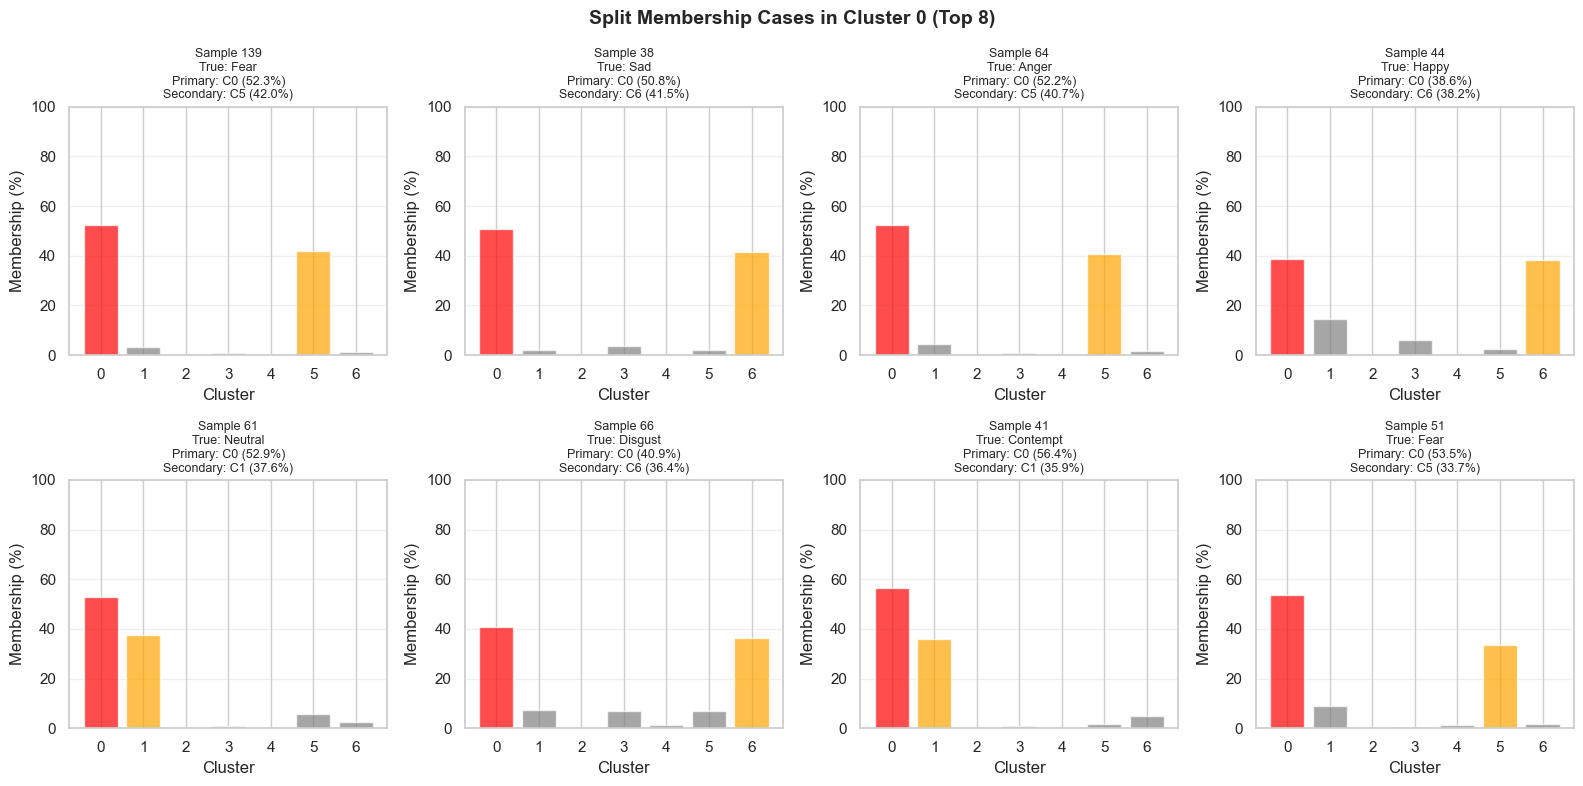


Split Membership Summary:
  Average primary membership: 49.70%
  Average secondary membership: 38.24%
  True label distribution:
    Fear: 2 (25.0%)
    Contempt: 1 (12.5%)
    Sad: 1 (12.5%)
    Happy: 1 (12.5%)
    Neutral: 1 (12.5%)
    Anger: 1 (12.5%)
    Disgust: 1 (12.5%)


In [15]:
# ---------------------------------------------------------------------------
# Visualization 1: Split Membership Cases in Cluster 0
# ---------------------------------------------------------------------------
if len(split_cases) > 0:
    # Show top 8 split cases
    n_show = min(8, len(split_cases))
    split_cases_sorted = sorted(split_cases, key=lambda x: x['secondary_membership'], reverse=True)[:n_show]
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    for plot_idx, case in enumerate(split_cases_sorted):
        ax = axes[plot_idx]
        membership_vec = case['membership_vector']
        
        # Create bar chart of memberships
        clusters = range(len(membership_vec))
        colors = ['red' if i == case['primary_cluster'] else 
                 ('orange' if i == case['secondary_cluster'] else 'gray') 
                 for i in clusters]
        
        bars = ax.bar(clusters, membership_vec * 100, color=colors, alpha=0.7)
        ax.set_ylim(0, 100)
        ax.set_xlabel('Cluster')
        ax.set_ylabel('Membership (%)')
        ax.set_title(f"Sample {case['index']}\nTrue: {case['true_label']}\n"
                    f"Primary: C{case['primary_cluster']} ({case['primary_membership']:.1%})\n"
                    f"Secondary: C{case['secondary_cluster']} ({case['secondary_membership']:.1%})",
                    fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_xticks(clusters)
    
    # Hide unused subplots
    for i in range(n_show, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(f'Split Membership Cases in Cluster 0 (Top {n_show})', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print(f"\nSplit Membership Summary:")
    print(f"  Average primary membership: {np.mean([c['primary_membership'] for c in split_cases]):.2%}")
    print(f"  Average secondary membership: {np.mean([c['secondary_membership'] for c in split_cases]):.2%}")
    print(f"  True label distribution:")
    true_labels_split = [c['true_label'] for c in split_cases]
    label_counts = pd.Series(true_labels_split).value_counts()
    for label, count in label_counts.items():
        print(f"    {label}: {count} ({100*count/len(split_cases):.1f}%)")
else:
    print("No split membership cases found in Cluster 0.")



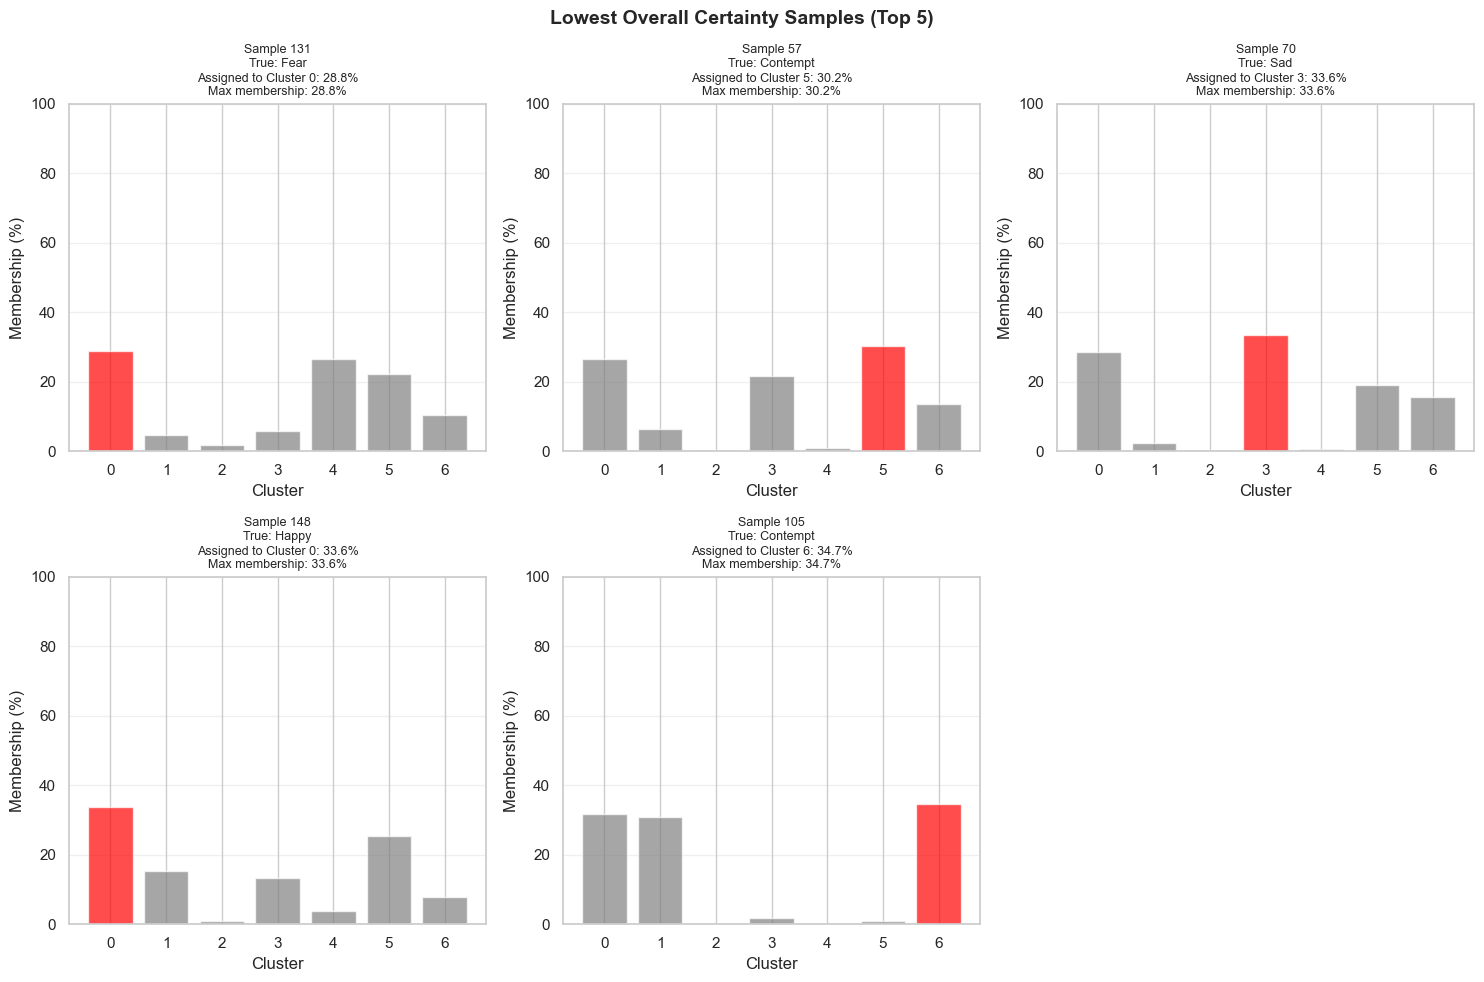


Lowest Certainty Samples Summary:
  Average assigned cluster membership: 32.20%
  Average max membership: 32.20%
  Cluster distribution:
    Cluster 0: 2 (40.0%)
    Cluster 5: 1 (20.0%)
    Cluster 3: 1 (20.0%)
    Cluster 6: 1 (20.0%)
  True label distribution:
    Contempt: 2 (40.0%)
    Fear: 1 (20.0%)
    Sad: 1 (20.0%)
    Happy: 1 (20.0%)


In [16]:
# ---------------------------------------------------------------------------
# Visualization 2: Lowest Overall Certainty Samples (Top 5)
# ---------------------------------------------------------------------------
if len(low_conf_outliers) > 0:
    # Show all 5 (or fewer if less available)
    n_show = len(low_conf_outliers)
    
    n_cols = 3
    n_rows = (n_show + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    if n_rows == 1:
        axes = axes if isinstance(axes, np.ndarray) else [axes]
    else:
        axes = axes.flatten()
    
    for plot_idx, case in enumerate(low_conf_outliers):
        ax = axes[plot_idx]
        membership_vec = case['membership_vector']
        assigned_cluster = case['assigned_cluster']
        
        # Create bar chart of memberships
        clusters = range(len(membership_vec))
        colors = ['red' if i == assigned_cluster else 'gray' for i in clusters]
        
        bars = ax.bar(clusters, membership_vec * 100, color=colors, alpha=0.7)
        ax.set_ylim(0, 100)
        ax.set_xlabel('Cluster')
        ax.set_ylabel('Membership (%)')
        ax.set_title(f"Sample {case['index']}\nTrue: {case['true_label']}\n"
                    f"Assigned to Cluster {assigned_cluster}: {case['assigned_membership']:.1%}\n"
                    f"Max membership: {case['max_membership']:.1%}",
                    fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_xticks(clusters)
    
    # Hide unused subplots
    for i in range(n_show, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(f'Lowest Overall Certainty Samples (Top {n_show})', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print(f"\nLowest Certainty Samples Summary:")
    print(f"  Average assigned cluster membership: {np.mean([c['assigned_membership'] for c in low_conf_outliers]):.2%}")
    print(f"  Average max membership: {np.mean([c['max_membership'] for c in low_conf_outliers]):.2%}")
    print(f"  Cluster distribution:")
    cluster_dist = pd.Series([c['assigned_cluster'] for c in low_conf_outliers]).value_counts()
    for cluster, count in cluster_dist.items():
        print(f"    Cluster {cluster}: {count} ({100*count/len(low_conf_outliers):.1f}%)")
    print(f"  True label distribution:")
    true_labels_outliers = [c['true_label'] for c in low_conf_outliers]
    label_counts = pd.Series(true_labels_outliers).value_counts()
    for label, count in label_counts.items():
        print(f"    {label}: {count} ({100*count/len(low_conf_outliers):.1f}%)")
else:
    print("No low-confidence samples found.")




VISUALIZING SPLIT MEMBERSHIP IMAGES


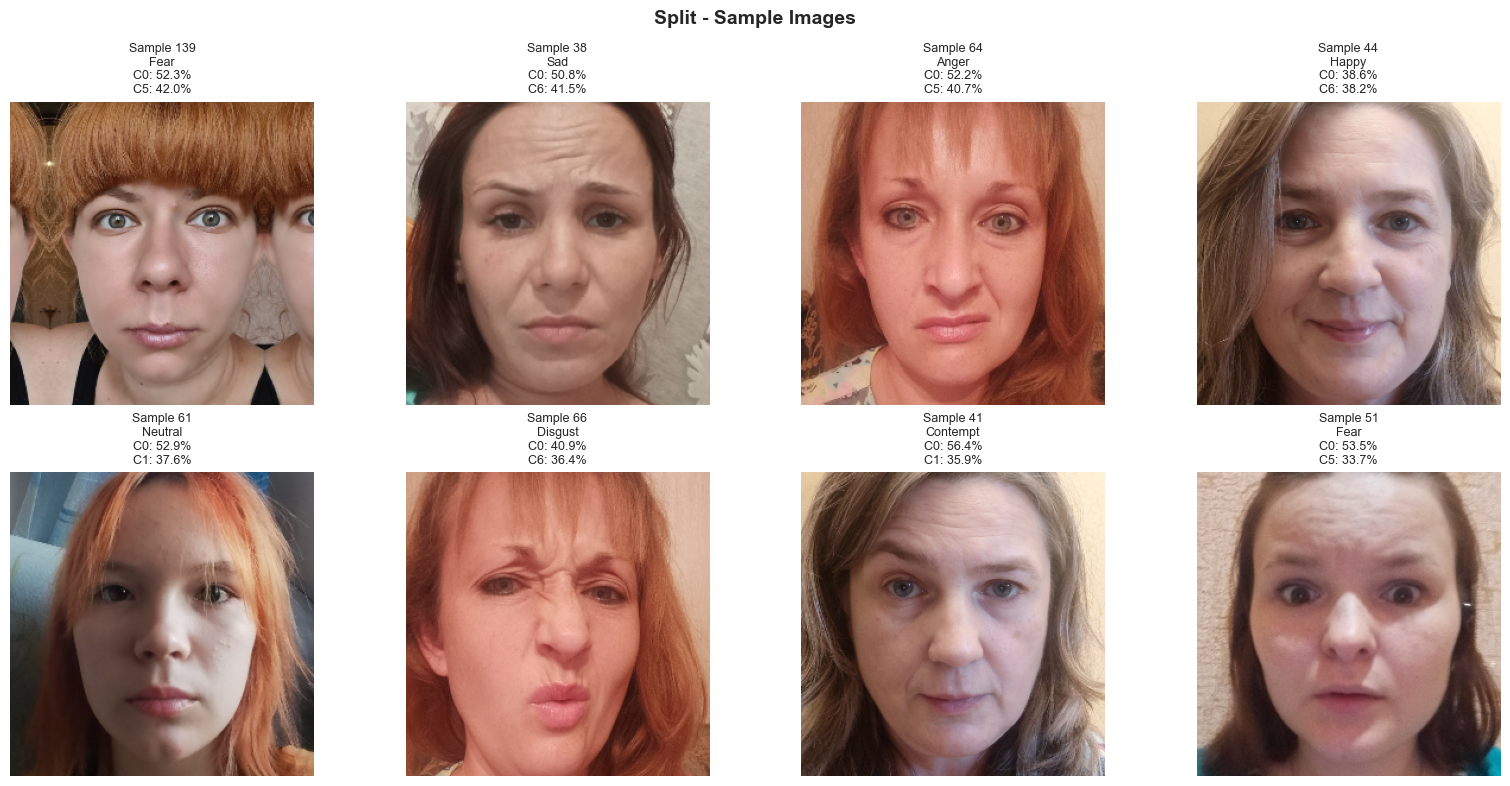


VISUALIZING LOWEST CERTAINTY SAMPLE IMAGES


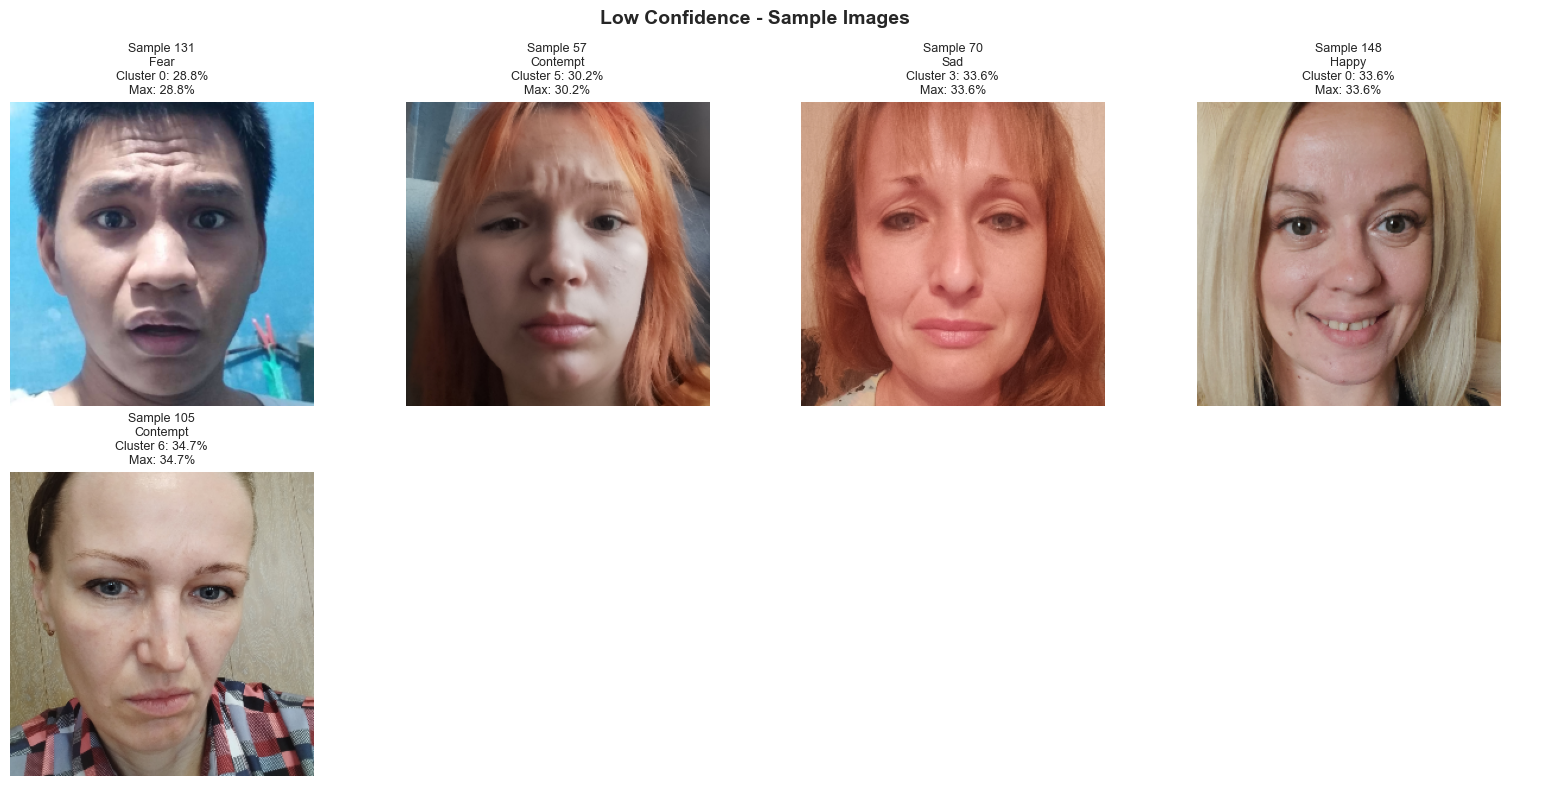

In [17]:
# ---------------------------------------------------------------------------
# Visualization 3: Show Images of Edge Cases
# ---------------------------------------------------------------------------
import cv2

def visualize_edge_case_images(cases: List[Dict], case_type: str, max_images: int = 8):
    """Visualize images for edge cases."""
    if len(cases) == 0:
        print(f"No {case_type} cases to visualize.")
        return
    
    # Determine dataset folder
    DATASET_FOLDER = _BASE_DIR / 'facial_emotion_recognition_aligned'
    if not DATASET_FOLDER.exists():
        DATASET_FOLDER = _BASE_DIR / 'facial_emotion_recognition_preprocessed2'
    
    # Load CSV to get image paths
    df = pd.read_csv(DEFAULT_OUTPUT_FILE)
    if 'Image_Path' not in df.columns:
        df['Image_Path'] = df.apply(
            lambda row: f"{row['Person_ID']}/{row['Image_Name']}", 
            axis=1
        )
    
    # Use selected_indices to map back to original CSV
    n_show = min(max_images, len(cases))
    cases_to_show = cases[:n_show]
    
    n_cols = 4
    n_rows = (n_show + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    if n_rows == 1:
        axes = axes if isinstance(axes, np.ndarray) else [axes]
    else:
        axes = axes.flatten()
    
    for plot_idx, case in enumerate(cases_to_show):
        ax = axes[plot_idx]
        idx_in_selected = case['index']
        
        # Map to original CSV index
        if selected_idx is not None and idx_in_selected < len(selected_idx):
            original_idx = selected_idx[idx_in_selected]
            if original_idx < len(df):
                row = df.iloc[original_idx]
                image_path = DATASET_FOLDER / row['Image_Path']
                
                if image_path.exists():
                    img = cv2.imread(str(image_path))
                    if img is not None:
                        if len(img.shape) == 3:
                            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                        ax.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
                    else:
                        ax.text(0.5, 0.5, 'Image\nnot found', ha='center', va='center')
                else:
                    ax.text(0.5, 0.5, f'Path not found:\n{image_path.name}', 
                           ha='center', va='center', fontsize=8)
            else:
                ax.text(0.5, 0.5, 'Index\nout of range', ha='center', va='center')
        else:
            ax.text(0.5, 0.5, 'Index\nmapping error', ha='center', va='center')
        
        ax.axis('off')
        if case_type == 'split':
            ax.set_title(f"Sample {case['index']}\n{case['true_label']}\n"
                        f"C{case['primary_cluster']}: {case['primary_membership']:.1%}\n"
                        f"C{case['secondary_cluster']}: {case['secondary_membership']:.1%}",
                        fontsize=9)
        else:
            ax.set_title(f"Sample {case['index']}\n{case['true_label']}\n"
                        f"Cluster {case['assigned_cluster']}: {case['assigned_membership']:.1%}\n"
                        f"Max: {case['max_membership']:.1%}",
                        fontsize=9)
    
    # Hide unused subplots
    for i in range(n_show, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(f'{case_type.replace("_", " ").title()} - Sample Images', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Visualize split membership images
if len(split_cases) > 0:
    print("\n" + "=" * 80)
    print("VISUALIZING SPLIT MEMBERSHIP IMAGES")
    print("=" * 80)
    split_cases_sorted = sorted(split_cases, key=lambda x: x['secondary_membership'], reverse=True)
    visualize_edge_case_images(split_cases_sorted, 'split', max_images=8)

# Visualize low-confidence outlier images
if len(low_conf_outliers) > 0:
    print("\n" + "=" * 80)
    print("VISUALIZING LOWEST CERTAINTY SAMPLE IMAGES")
    print("=" * 80)
    visualize_edge_case_images(low_conf_outliers, 'low_confidence', max_images=5)



In [18]:
# ---------------------------------------------------------------------------
# High Probability Samples in Cluster 0
# ---------------------------------------------------------------------------
def find_high_probability_samples(memberships: np.ndarray, hard_labels: np.ndarray,
                                 true_labels: np.ndarray, cluster_id: int = 0,
                                 top_n: int = 5):
    """
    Find samples with highest membership probability in a specific cluster.
    
    Args:
        memberships: Membership matrix (n_clusters, n_samples)
        hard_labels: Hard cluster assignments (n_samples,)
        true_labels: True emotion labels (n_samples,)
        cluster_id: Cluster to analyze (default: 0)
        top_n: Number of top samples to return (default: 5)
    
    Returns:
        List of dictionaries with sample information
    """
    n_samples = memberships.shape[1]
    
    high_prob_samples = []
    for idx in range(n_samples):
        membership_vec = memberships[:, idx]
        cluster_membership = membership_vec[cluster_id]
        
        high_prob_samples.append({
            'index': idx,
            'true_label': true_labels[idx],
            'assigned_cluster': hard_labels[idx],
            'cluster_membership': cluster_membership,
            'membership_vector': membership_vec
        })
    
    # Sort by cluster membership (highest first) and take top N
    high_prob_samples_sorted = sorted(high_prob_samples, 
                                     key=lambda x: x['cluster_membership'], 
                                     reverse=True)[:top_n]
    
    return high_prob_samples_sorted


# Find top 5 samples with highest probability in Cluster 0
print("=" * 80)
print("HIGH PROBABILITY SAMPLES IN CLUSTER 0")
print("=" * 80)

high_prob_cluster0 = find_high_probability_samples(
    memberships, hard_labels, y_labels, cluster_id=0, top_n=5
)

print(f"\nTop 5 samples with highest membership in Cluster 0:")
for i, case in enumerate(high_prob_cluster0, 1):
    print(f"  {i}. Sample {case['index']}: True={case['true_label']}, "
          f"Cluster 0 membership={case['cluster_membership']:.2%}, "
          f"Assigned to Cluster {case['assigned_cluster']}")



HIGH PROBABILITY SAMPLES IN CLUSTER 0

Top 5 samples with highest membership in Cluster 0:
  1. Sample 109: True=Neutral, Cluster 0 membership=98.77%, Assigned to Cluster 0
  2. Sample 91: True=Fear, Cluster 0 membership=97.70%, Assigned to Cluster 0
  3. Sample 136: True=Anger, Cluster 0 membership=96.88%, Assigned to Cluster 0
  4. Sample 93: True=Neutral, Cluster 0 membership=96.12%, Assigned to Cluster 0
  5. Sample 121: True=Contempt, Cluster 0 membership=93.15%, Assigned to Cluster 0


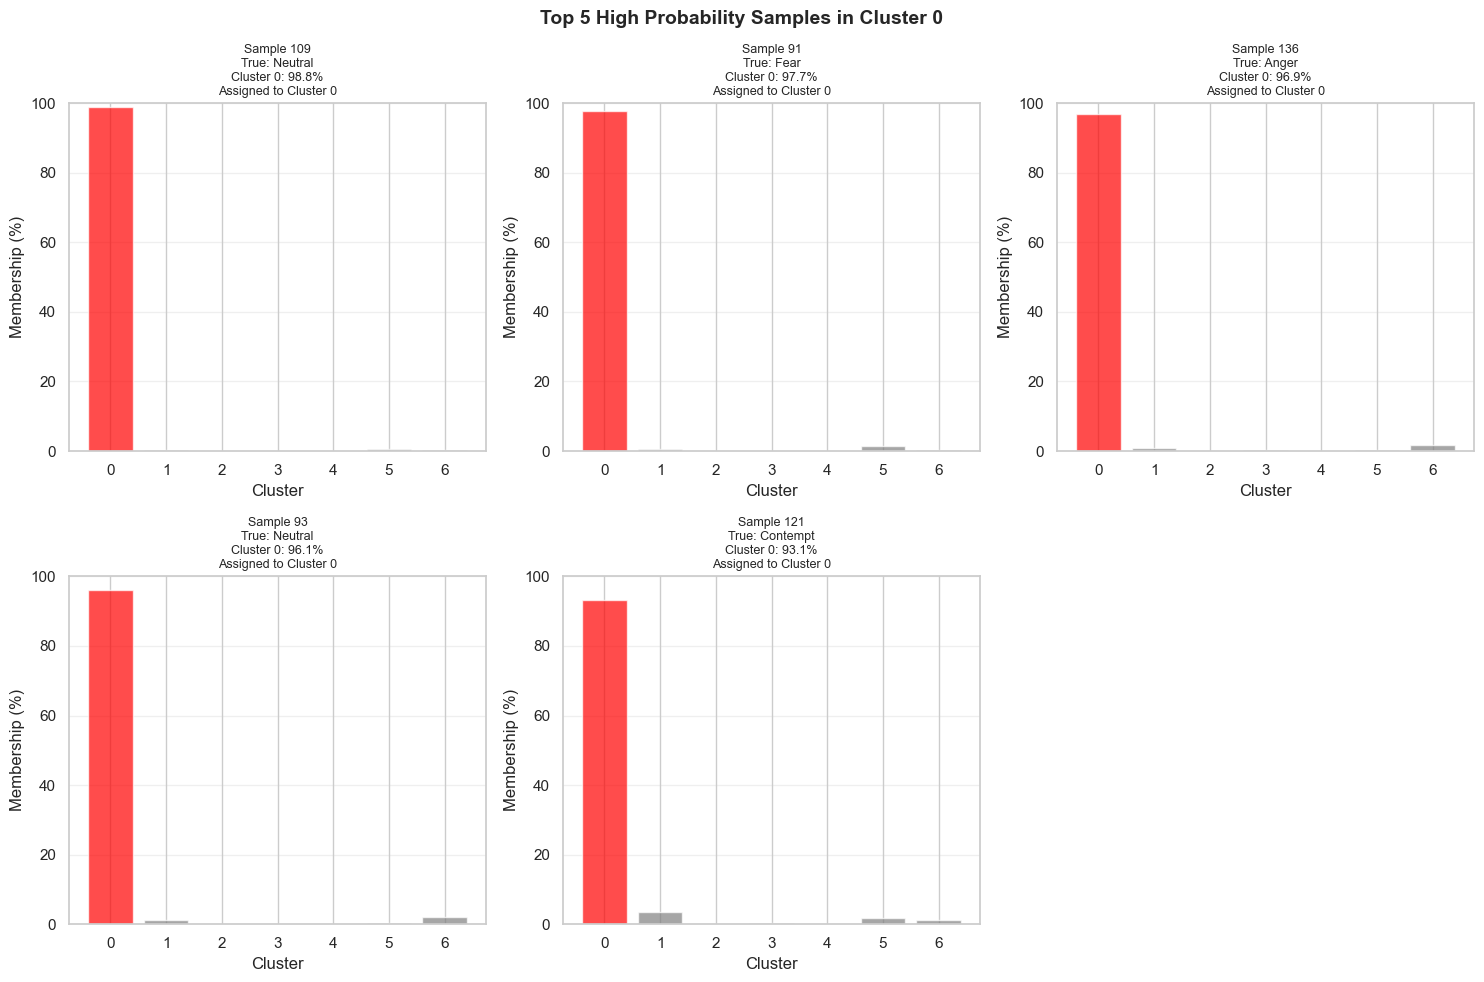


High Probability Cluster 0 Samples Summary:
  Average Cluster 0 membership: 96.52%
  True label distribution:
    Neutral: 2 (40.0%)
    Fear: 1 (20.0%)
    Anger: 1 (20.0%)
    Contempt: 1 (20.0%)


In [19]:
# ---------------------------------------------------------------------------
# Visualization: High Probability Samples in Cluster 0
# ---------------------------------------------------------------------------
if len(high_prob_cluster0) > 0:
    n_show = len(high_prob_cluster0)
    
    # Bar chart visualization
    n_cols = 3
    n_rows = (n_show + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    if n_rows == 1:
        axes = axes if isinstance(axes, np.ndarray) else [axes]
    else:
        axes = axes.flatten()
    
    for plot_idx, case in enumerate(high_prob_cluster0):
        ax = axes[plot_idx]
        membership_vec = case['membership_vector']
        
        # Create bar chart of memberships
        clusters = range(len(membership_vec))
        colors = ['red' if i == 0 else 'gray' for i in clusters]
        
        bars = ax.bar(clusters, membership_vec * 100, color=colors, alpha=0.7)
        ax.set_ylim(0, 100)
        ax.set_xlabel('Cluster')
        ax.set_ylabel('Membership (%)')
        ax.set_title(f"Sample {case['index']}\nTrue: {case['true_label']}\n"
                    f"Cluster 0: {case['cluster_membership']:.1%}\n"
                    f"Assigned to Cluster {case['assigned_cluster']}",
                    fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_xticks(clusters)
    
    # Hide unused subplots
    for i in range(n_show, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(f'Top {n_show} High Probability Samples in Cluster 0', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print(f"\nHigh Probability Cluster 0 Samples Summary:")
    print(f"  Average Cluster 0 membership: {np.mean([c['cluster_membership'] for c in high_prob_cluster0]):.2%}")
    print(f"  True label distribution:")
    true_labels_high = [c['true_label'] for c in high_prob_cluster0]
    label_counts = pd.Series(true_labels_high).value_counts()
    for label, count in label_counts.items():
        print(f"    {label}: {count} ({100*count/len(high_prob_cluster0):.1f}%)")
else:
    print("No high probability samples found in Cluster 0.")




VISUALIZING HIGH PROBABILITY CLUSTER 0 IMAGES


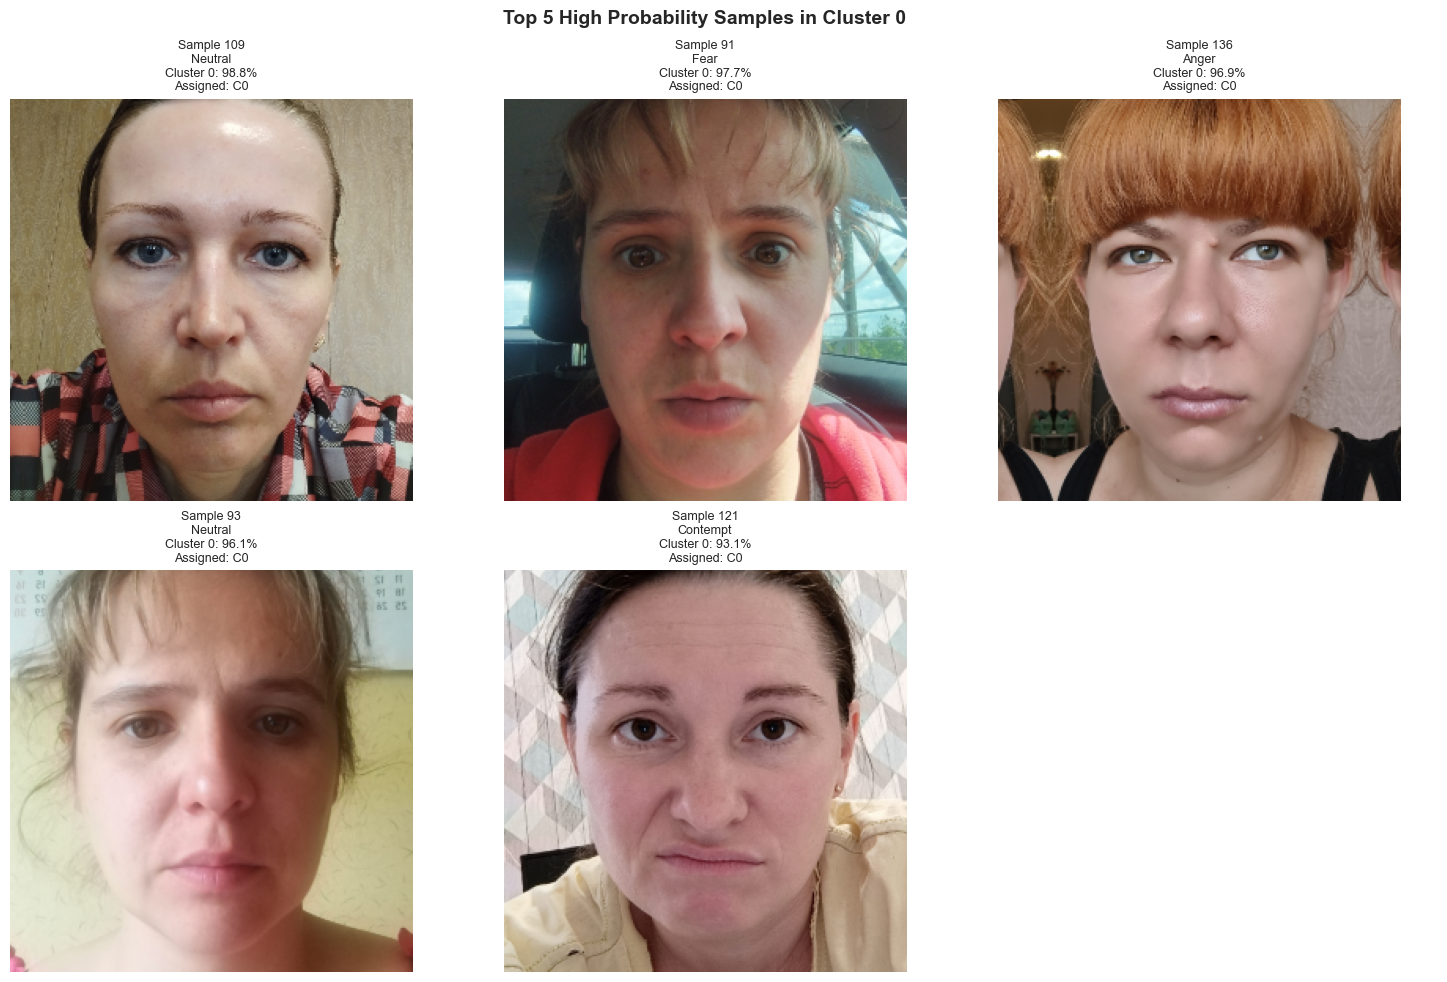

In [20]:
# ---------------------------------------------------------------------------
# Visualize Images of High Probability Cluster 0 Samples
# ---------------------------------------------------------------------------
if len(high_prob_cluster0) > 0:
    print("\n" + "=" * 80)
    print("VISUALIZING HIGH PROBABILITY CLUSTER 0 IMAGES")
    print("=" * 80)
    
    # Determine dataset folder
    DATASET_FOLDER = _BASE_DIR / 'facial_emotion_recognition_aligned'
    if not DATASET_FOLDER.exists():
        DATASET_FOLDER = _BASE_DIR / 'facial_emotion_recognition_preprocessed2'
    
    # Load CSV to get image paths
    df = pd.read_csv(DEFAULT_OUTPUT_FILE)
    if 'Image_Path' not in df.columns:
        df['Image_Path'] = df.apply(
            lambda row: f"{row['Person_ID']}/{row['Image_Name']}", 
            axis=1
        )
    
    # Create image grid
    n_cols = 3
    n_rows = (len(high_prob_cluster0) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    if n_rows == 1:
        axes = axes if isinstance(axes, np.ndarray) else [axes]
    else:
        axes = axes.flatten()
    
    for plot_idx, case in enumerate(high_prob_cluster0):
        ax = axes[plot_idx]
        idx_in_selected = case['index']
        
        # Map to original CSV index
        if selected_idx is not None and idx_in_selected < len(selected_idx):
            original_idx = selected_idx[idx_in_selected]
            if original_idx < len(df):
                row = df.iloc[original_idx]
                image_path = DATASET_FOLDER / row['Image_Path']
                
                if image_path.exists():
                    img = cv2.imread(str(image_path))
                    if img is not None:
                        if len(img.shape) == 3:
                            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                        ax.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
                    else:
                        ax.text(0.5, 0.5, 'Image\nnot found', ha='center', va='center')
                else:
                    ax.text(0.5, 0.5, f'Path not found:\n{image_path.name}', 
                           ha='center', va='center', fontsize=8)
            else:
                ax.text(0.5, 0.5, 'Index\nout of range', ha='center', va='center')
        else:
            ax.text(0.5, 0.5, 'Index\nmapping error', ha='center', va='center')
        
        ax.axis('off')
        ax.set_title(f"Sample {case['index']}\n{case['true_label']}\n"
                    f"Cluster 0: {case['cluster_membership']:.1%}\n"
                    f"Assigned: C{case['assigned_cluster']}",
                    fontsize=9)
    
    # Hide unused subplots
    for i in range(len(high_prob_cluster0), len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(f'Top {len(high_prob_cluster0)} High Probability Samples in Cluster 0', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()



## Next Steps

- Adjust `SELECTED_EMOTIONS` or `FUZZIFIER_VALUES` to explore other subsets and softness levels.
- Compare the ARI/FPC pairs against the traditional clustering notebook to see whether fuzzy assignments offer a boost.
- Persist the `membership_df` table or save the hard labels if you plan to reuse them elsewhere in your pipeline.



In [21]:
# ---------------------------------------------------------------------------
# Final Evaluation: Silhouette Score and Adjusted Rand Index (ARI)
# ---------------------------------------------------------------------------
print("=" * 80)
print("FINAL CLUSTERING EVALUATION METRICS")
print("=" * 80)

# Compute Silhouette Score
# Silhouette score measures how similar an object is to its own cluster (cohesion) 
# compared to other clusters (separation). Range: [-1, 1], higher is better.
silhouette = silhouette_score(X_scaled, hard_labels)
print(f"\nSilhouette Score: {silhouette:.4f}")
print(f"  Interpretation: {'Good' if silhouette > 0.5 else 'Moderate' if silhouette > 0.25 else 'Poor'}")
print(f"  Range: [-1, 1], where 1 = perfect clustering, 0 = overlapping clusters, -1 = misclassified")

# Compute/Retrieve Adjusted Rand Index (ARI)
# ARI measures the similarity between two data clusterings. Range: [-1, 1], higher is better.
ari = adjusted_rand_score(y_encoded, hard_labels)
print(f"\nAdjusted Rand Index (ARI): {ari:.4f}")
print(f"  Interpretation: {'Excellent' if ari > 0.7 else 'Good' if ari > 0.5 else 'Moderate' if ari > 0.3 else 'Poor'}")
print(f"  Range: [-1, 1], where 1 = perfect match with true labels, 0 = random labeling")

# Summary
print("\n" + "-" * 80)
print("SUMMARY")
print("-" * 80)
print(f"Clustering Method: Fuzzy C-Means")
print(f"  Number of clusters (c): {best_c}")
print(f"  Fuzzifier (m): {best_m:.2f}")
print(f"  Fuzzy Partition Coefficient (FPC): {final_result['fpc']:.4f}")
print(f"\nEvaluation Metrics:")
print(f"  Silhouette Score: {silhouette:.4f}")
print(f"  Adjusted Rand Index (ARI): {ari:.4f}")
print("=" * 80)

# Create a comparison DataFrame for easy reference
evaluation_df = pd.DataFrame({
    'Metric': ['Silhouette Score', 'Adjusted Rand Index (ARI)', 'Fuzzy Partition Coefficient (FPC)'],
    'Value': [silhouette, ari, final_result['fpc']],
    'Range': ['[-1, 1]', '[-1, 1]', '[0, 1]'],
    'Interpretation': [
        'Higher is better - measures cluster cohesion vs separation',
        'Higher is better - measures agreement with true labels',
        'Higher is better - measures fuzzy partition quality'
    ]
})

print("\nEvaluation Metrics Summary Table:")
print(evaluation_df.to_string(index=False))


FINAL CLUSTERING EVALUATION METRICS

Silhouette Score: 0.1906
  Interpretation: Poor
  Range: [-1, 1], where 1 = perfect clustering, 0 = overlapping clusters, -1 = misclassified

Adjusted Rand Index (ARI): 0.1157
  Interpretation: Poor
  Range: [-1, 1], where 1 = perfect match with true labels, 0 = random labeling

--------------------------------------------------------------------------------
SUMMARY
--------------------------------------------------------------------------------
Clustering Method: Fuzzy C-Means
  Number of clusters (c): 7
  Fuzzifier (m): 1.43
  Fuzzy Partition Coefficient (FPC): 0.6269

Evaluation Metrics:
  Silhouette Score: 0.1906
  Adjusted Rand Index (ARI): 0.1157

Evaluation Metrics Summary Table:
                           Metric    Value   Range                                             Interpretation
                 Silhouette Score 0.190580 [-1, 1] Higher is better - measures cluster cohesion vs separation
        Adjusted Rand Index (ARI) 0.115678 [-1,